# Titanic Dataset - Statistics & Probability

## Objective

The objective of this notebook is to apply statistical concepts to the cleaned Titanic dataset. The analysis focuses on descriptive statistics, probability distributions, hypothesis testing, and the distinction between correlation and causation.

The findings will provide statistical evidence that supports future machine learning models.

Import Libraries

In [242]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

from scipy import stats


Load the Dataset

In [243]:
titanic = pd.read_csv("../data/Titanic-Dataset.csv")

Overview of the Dataset

In [244]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [245]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [246]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [247]:
titanic.shape

(891, 12)

The cleaned Titanic dataset contains 891 passenger records and 12 variables describing passenger demographics, ticket information, family relationships, and survival status. Missing values were handled during Week 1–2, making the dataset suitable for statistical analysis.

# Descriptive Statistics

## Analysis of survival (Target variable)

In [248]:
titanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

Percentage of survivals

In [249]:
titanic["Survived"].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [250]:
titanic["Survived"].describe()

count    891.000000
mean       0.383838
std        0.486592
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Survived, dtype: float64

## Analysis of age

In [251]:
titanic["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [252]:
titanic["Age"].median()

np.float64(28.0)

In [253]:
titanic["Age"].mode()

0    24.0
Name: Age, dtype: float64

In [254]:
titanic["Age"].std()

np.float64(14.526497332334042)

In [255]:
titanic["Age"].skew()

np.float64(0.38910778230082704)

In [256]:
titanic["Age"].kurt()

np.float64(0.17827415364210353)

In [257]:
titanic["Age"].max()-titanic["Age"].min()

np.float64(79.58)

The Age variable represents the ages of passengers aboard the Titanic and was analyzed to understand the distribution of passenger ages after handling missing values during data cleaning.

The average passenger age is approximately 29.70 years, while the median age is 28.00 years. Since the mean is slightly higher than the median, the age distribution exhibits a slight positive skew, indicating that a relatively small number of older passengers increase the average age.

The mode of 24 years indicates that this was the most frequently occurring passenger age in the dataset.

The range of passenger ages is 79.58 years, spanning from approximately 0.42 years (the youngest passenger) to 80 years (the oldest passenger). This wide range demonstrates that the Titanic carried passengers from infants to elderly adults.

The variance of 211.02 years² and the standard deviation of 14.53 years indicate a moderate level of variability in passenger ages. On average, passenger ages differ from the mean by approximately 14.5 years, suggesting a fairly broad spread of ages around the average.

The skewness value of 0.389 indicates a slightly positively skewed (right-skewed) distribution. Most passengers were young to middle-aged adults, while a relatively small number of older passengers created a longer right tail.

The kurtosis value of 0.178 is slightly positive, indicating a distribution that is slightly leptokurtic. This suggests that the age distribution has marginally heavier tails than a normal distribution, although the difference is small. Overall, the distribution remains relatively close to normal.

Statistical Conclusion

Overall, the Age variable exhibits a near-normal distribution with a slight positive skew and moderate variability. Most passengers were young adults, with relatively few elderly passengers. Compared to variables such as Fare, the age distribution is much closer to normal and contains fewer extreme observations. While age provides useful descriptive information about the passenger population, previous exploratory analysis indicated that it has only a weak relationship with passenger survival, making it a relatively weak standalone predictor for predictive modeling.

# Fare

In [258]:
titanic["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [259]:
titanic["Fare"].median()

np.float64(14.4542)

In [260]:
titanic["Fare"].mode()

0    8.05
Name: Fare, dtype: float64

In [261]:
titanic["Fare"].var()

np.float64(2469.436845743116)

In [262]:
titanic["Fare"].std()

np.float64(49.6934285971809)

In [263]:
titanic["Fare"].skew()

np.float64(4.787316519674893)

In [264]:
titanic["Fare"].kurt()

np.float64(33.39814088089868)

In [265]:
titanic["Fare"].max()-titanic["Fare"].min()

np.float64(512.3292)

## Probability Distributions

Survival Probability

In [266]:
survival_probability = titanic["Survived"].value_counts(normalize=True) * 100
survival_probability

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

Probabilistic analysis od the survived column reveals that only 38.38% of passengers survived while 61.62% of passengers perrished or did not survive.

Passenger Class Probability

In [267]:
pclass_probabilities = titanic["Pclass"].value_counts(normalize=True) * 100
pclass_probabilities

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64

From analysis of the passenger class probabilities. 55% of passengers , who were the majority belonged to the 3rd class, 24% of passengers to the 1st class while 20% of passengers belong to the 2nd class.

## Sex

In [268]:
titanic["Sex"].value_counts(normalize=True) * 100

Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64

Probabilistic analysis of sex reveals that 64.76% of the passengers were male while 35.24% were female 

# Conditional Probablity

In [269]:
pd.crosstab(titanic["Sex"], titanic["Survived"], normalize="index") * 100

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


Analysis of survival based on sex reveals that 74.20% of females survived while only 18.89% of males survived 

## Probability Distribution graphs

Histogram for age distribution

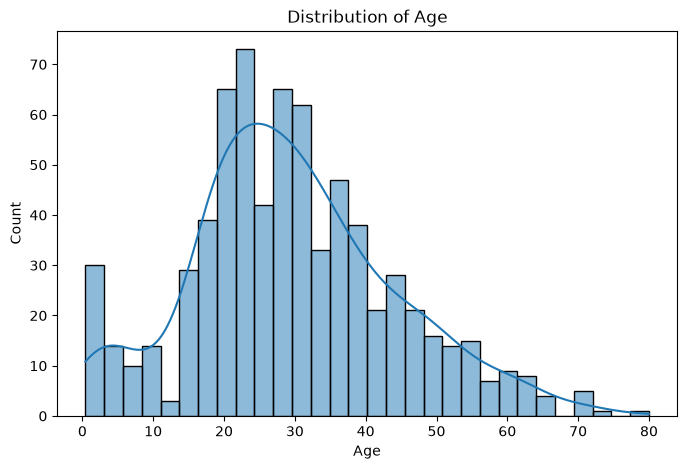

In [270]:
plt.figure(figsize=(8, 5))
sns.histplot(titanic["Age"], bins=30, kde=True)
plt.title("Distribution of Age")
plt.show()

The distribution graph of age reveals thatmajority of the people are from the from younger and middle ages with a lot of outliers in the older ages.

Fare

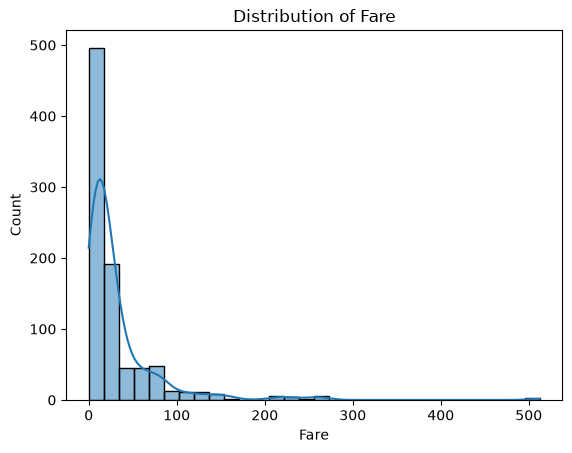

In [271]:
sns.histplot(titanic["Fare"], bins=30, kde=True)
plt.title("Distribution of Fare")
plt.show()

The fare histogram reveals that the fare column was very varied with majority of the people paying a small amount of fare of between 0 to 100. The fare is very skewed towards the right with a lot of outliers and a very small minority paying very hish fares of upto 500.

## Survival

<Axes: xlabel='Survived', ylabel='count'>

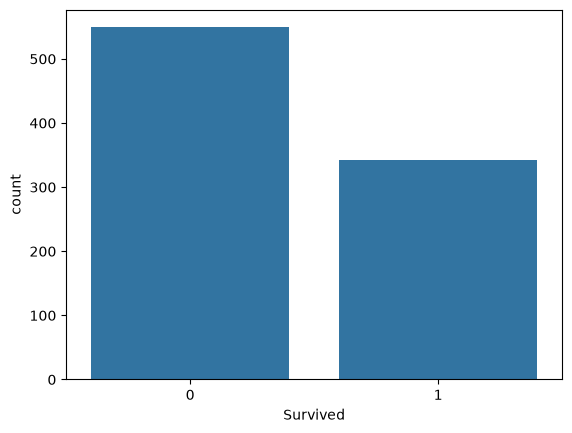

In [272]:
sns.countplot(data=titanic, x="Survived")

From the survival countplot more people died while a smaller percentage survived.

## Passenger Class

<Axes: xlabel='Pclass', ylabel='count'>

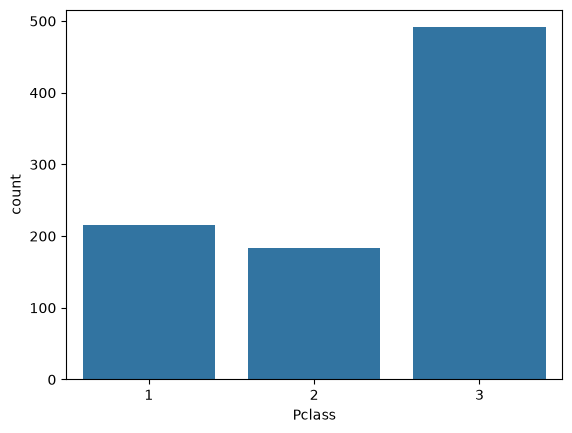

In [273]:
sns.countplot(data=titanic, x="Pclass")

# Hypothesis Testing

Relation of sex to survival

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(titanic["Sex"], titanic["Survived"])

contingency_table


NameError: name 'pd' is not defined